# Task 2 & 3: Data Ingestion, HDFS Upload and Spark Processing
## RSNA Bone Age Dataset — Big Data Pipeline

## Step 1: Initialize PySpark Session

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, stddev, min, max, when, isnan
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName('RSNA_BoneAge_Pipeline') \
    .master('local[*]') \
    .config('spark.driver.memory', '4g') \
    .config('spark.executor.memory', '4g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')
print('SparkSession initialized successfully.')

Spark version: 3.1.1
SparkSession initialized successfully.


## Step 2: Load CSV Metadata

In [2]:
schema = StructType([
    StructField('id',      IntegerType(), True),
    StructField('boneage', FloatType(),   True),
    StructField('male',    BooleanType(), True)
])

df_train = spark.read.csv(
    'boneage-training-dataset.csv',
    header=True,
    schema=schema
)

print(f'Total training records: {df_train.count()}')
df_train.printSchema()
df_train.show(10)

Total training records: 12611
root
 |-- id: integer (nullable = true)
 |-- boneage: float (nullable = true)
 |-- male: boolean (nullable = true)

+----+-------+-----+
|  id|boneage| male|
+----+-------+-----+
|1377|  180.0|false|
|1378|   12.0|false|
|1379|   94.0|false|
|1380|  120.0| true|
|1381|   82.0|false|
|1382|  138.0| true|
|1383|  150.0| true|
|1384|  156.0| true|
|1385|   36.0| true|
|1387|  138.0| true|
+----+-------+-----+
only showing top 10 rows



## Step 3: Data Wrangling and Transformations

In [3]:
print('=== Null Value Check ===')
df_train.select([count(when(col(c).isNull(), c)).alias(c) for c in df_train.columns]).show()

df_enriched = df_train \
    .withColumn('boneage_years', col('boneage') / 12.0) \
    .withColumn('gender', when(col('male') == True, 'Male').otherwise('Female')) \
    .withColumn('age_group',
        when(col('boneage') < 60,  'Infant (0-5y)')
        .when(col('boneage') < 120, 'Child (5-10y)')
        .when(col('boneage') < 168, 'Pre-teen (10-14y)')
        .otherwise('Teenager (14y+)'))

print('=== Enriched Dataset Sample ===')
df_enriched.show(10)
print(f'Total enriched records: {df_enriched.count()}')

=== Null Value Check ===
+---+-------+----+
| id|boneage|male|
+---+-------+----+
|  0|      0|   0|
+---+-------+----+

=== Enriched Dataset Sample ===
+----+-------+-----+-----------------+------+-----------------+
|  id|boneage| male|    boneage_years|gender|        age_group|
+----+-------+-----+-----------------+------+-----------------+
|1377|  180.0|false|             15.0|Female|  Teenager (14y+)|
|1378|   12.0|false|              1.0|Female|    Infant (0-5y)|
|1379|   94.0|false|7.833333333333333|Female|    Child (5-10y)|
|1380|  120.0| true|             10.0|  Male|Pre-teen (10-14y)|
|1381|   82.0|false|6.833333333333333|Female|    Child (5-10y)|
|1382|  138.0| true|             11.5|  Male|Pre-teen (10-14y)|
|1383|  150.0| true|             12.5|  Male|Pre-teen (10-14y)|
|1384|  156.0| true|             13.0|  Male|Pre-teen (10-14y)|
|1385|   36.0| true|              3.0|  Male|    Infant (0-5y)|
|1387|  138.0| true|             11.5|  Male|Pre-teen (10-14y)|
+----+-------+-

## Step 4: Exploratory Statistics with Spark

In [4]:
print('=== Summary Statistics ===')
df_enriched.describe(['boneage', 'boneage_years']).show()

print('=== Gender Distribution ===')
df_enriched.groupBy('gender').agg(
    count('id').alias('count'),
    avg('boneage').alias('avg_boneage_months'),
    stddev('boneage').alias('stddev_boneage')
).show()

print('=== Age Group Distribution ===')
df_enriched.groupBy('age_group').agg(
    count('id').alias('count'),
    avg('boneage').alias('avg_boneage')
).orderBy('avg_boneage').show()

print('=== Min/Max Bone Age by Gender ===')
df_enriched.groupBy('gender').agg(
    min('boneage').alias('min_months'),
    max('boneage').alias('max_months')
).show()

=== Summary Statistics ===
+-------+-----------------+-------------------+
|summary|          boneage|      boneage_years|
+-------+-----------------+-------------------+
|  count|            12611|              12611|
|   mean|127.3207517246848| 10.610062643723515|
| stddev| 41.1820213993963|  3.431835116616352|
|    min|              1.0|0.08333333333333333|
|    max|            228.0|               19.0|
+-------+-----------------+-------------------+

=== Gender Distribution ===
+------+-----+------------------+------------------+
|gender|count|avg_boneage_months|    stddev_boneage|
+------+-----+------------------+------------------+
|Female| 5778|117.88023537556248|37.908111898417395|
|  Male| 6833| 135.3036733499195| 42.14316182574338|
+------+-----+------------------+------------------+

=== Age Group Distribution ===
+-----------------+-----+------------------+
|        age_group|count|       avg_boneage|
+-----------------+-----+------------------+
|    Infant (0-5y)|  801| 3

## Step 5: Write Processed Data to Hive Table

In [5]:
# Drop existing database and table to avoid conflicts
spark.sql('DROP TABLE IF EXISTS boneage_db.patient_records')
spark.sql('DROP DATABASE IF EXISTS boneage_db CASCADE')

# Create fresh database and table
spark.sql('CREATE DATABASE boneage_db')
spark.sql('USE boneage_db')

df_enriched.write \
    .mode('overwrite') \
    .saveAsTable('boneage_db.patient_records')

print('Hive table created: boneage_db.patient_records')
spark.sql('SHOW TABLES IN boneage_db').show()
spark.sql('SELECT COUNT(*) as total FROM boneage_db.patient_records').show()

Hive table created: boneage_db.patient_records
+----------+---------------+-----------+
|  database|      tableName|isTemporary|
+----------+---------------+-----------+
|boneage_db|patient_records|      false|
+----------+---------------+-----------+

+-----+
|total|
+-----+
|12611|
+-----+



## Step 6: HiveQL Queries for Exploratory Analysis

In [6]:
print('=== HiveQL Query 1: Average Bone Age by Gender ===')
spark.sql('''
    SELECT gender,
           COUNT(*) AS patient_count,
           ROUND(AVG(boneage), 2) AS avg_bone_age_months,
           ROUND(AVG(boneage_years), 2) AS avg_bone_age_years
    FROM boneage_db.patient_records
    GROUP BY gender
    ORDER BY avg_bone_age_months DESC
''').show()

print('=== HiveQL Query 2: Patient Distribution by Age Group ===')
spark.sql('''
    SELECT age_group,
           COUNT(*) AS patient_count,
           ROUND(MIN(boneage), 1) AS min_months,
           ROUND(MAX(boneage), 1) AS max_months
    FROM boneage_db.patient_records
    GROUP BY age_group
    ORDER BY min_months
''').show()

print('=== HiveQL Query 3: Gender Breakdown Within Age Groups ===')
spark.sql('''
    SELECT age_group, gender,
           COUNT(*) AS count,
           ROUND(AVG(boneage), 2) AS avg_boneage
    FROM boneage_db.patient_records
    GROUP BY age_group, gender
    ORDER BY age_group, gender
''').show(20)

=== HiveQL Query 1: Average Bone Age by Gender ===
+------+-------------+-------------------+------------------+
|gender|patient_count|avg_bone_age_months|avg_bone_age_years|
+------+-------------+-------------------+------------------+
|  Male|         6833|              135.3|             11.28|
|Female|         5778|             117.88|              9.82|
+------+-------------+-------------------+------------------+

=== HiveQL Query 2: Patient Distribution by Age Group ===
+-----------------+-------------+----------+----------+
|        age_group|patient_count|min_months|max_months|
+-----------------+-------------+----------+----------+
|    Infant (0-5y)|          801|       1.0|      58.0|
|    Child (5-10y)|         3487|      60.0|     118.0|
|Pre-teen (10-14y)|         6222|     120.0|     167.0|
|  Teenager (14y+)|         2101|     168.0|     228.0|
+-----------------+-------------+----------+----------+

=== HiveQL Query 3: Gender Breakdown Within Age Groups ===
+---------

## Step 7: Spark vs Hive Performance Comparison

In [7]:
import time

start = time.time()
df_enriched.groupBy('gender').agg(
    count('id').alias('count'),
    avg('boneage').alias('avg_boneage')
).collect()
spark_time = time.time() - start

start = time.time()
spark.sql('''
    SELECT gender, COUNT(*) as count, AVG(boneage) as avg_boneage
    FROM boneage_db.patient_records
    GROUP BY gender
''').collect()
hive_time = time.time() - start

print(f'Spark DataFrame API execution time: {spark_time:.3f} seconds')
print(f'HiveQL execution time:              {hive_time:.3f} seconds')
print()
print('=== Comparison Summary ===')
print('Spark DataFrame API: Better for iterative ML pipelines and real-time processing.')
print('HiveQL: Better for batch analytics, SQL-familiar users, and structured reporting.')

Spark DataFrame API execution time: 1.941 seconds
HiveQL execution time:              1.106 seconds

=== Comparison Summary ===
Spark DataFrame API: Better for iterative ML pipelines and real-time processing.
HiveQL: Better for batch analytics, SQL-familiar users, and structured reporting.


## Step 8: Visualisations

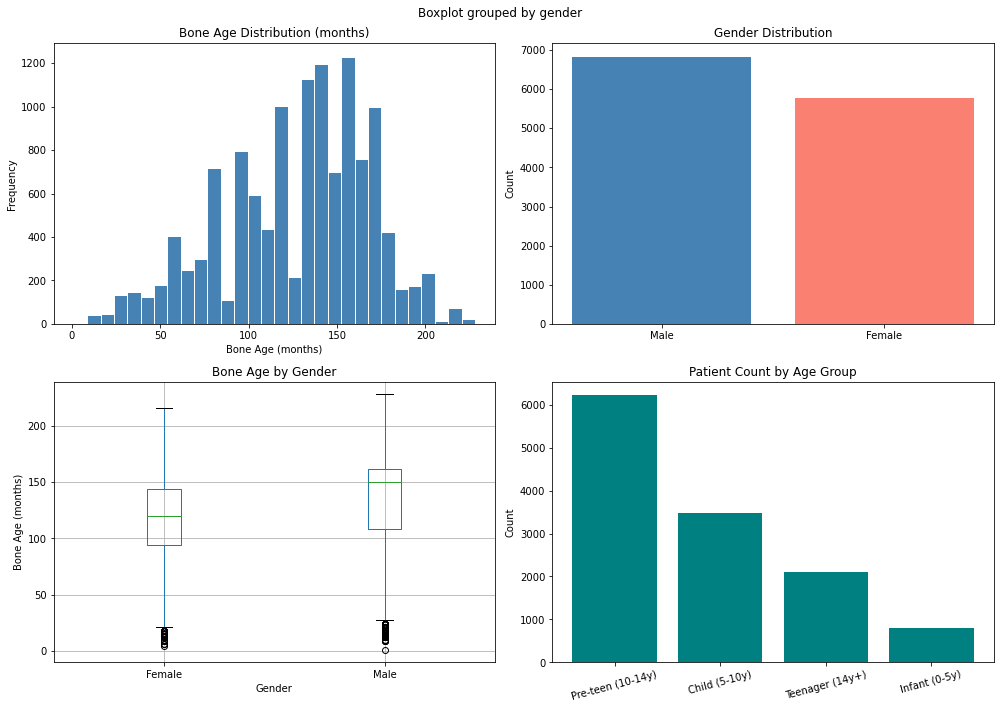

EDA plots saved.


In [8]:
pdf = df_enriched.toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RSNA Bone Age Dataset — Exploratory Analysis', fontsize=16)

axes[0,0].hist(pdf['boneage'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Bone Age Distribution (months)')
axes[0,0].set_xlabel('Bone Age (months)')
axes[0,0].set_ylabel('Frequency')

gender_counts = pdf['gender'].value_counts()
axes[0,1].bar(gender_counts.index, gender_counts.values, color=['steelblue','salmon'])
axes[0,1].set_title('Gender Distribution')
axes[0,1].set_ylabel('Count')

pdf.boxplot(column='boneage', by='gender', ax=axes[1,0])
axes[1,0].set_title('Bone Age by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Bone Age (months)')

age_counts = pdf['age_group'].value_counts()
axes[1,1].bar(age_counts.index, age_counts.values, color='teal')
axes[1,1].set_title('Patient Count by Age Group')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/home/jovyan/work/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')